# Marketing Funnel & Conversion Performance Analysis
### Bank Marketing Campaign Dataset (UCI Machine Learning Repository)

**Goal:** Analyze how leads move through a marketing/sales funnel — from being contacted, to engaging in
conversation, to converting into a customer (subscribing to a term deposit) — and identify where the
biggest drop-offs happen and which channels/segments convert best.

**Dataset:** `bank-additional-full.csv` — 41,188 client records from a Portuguese bank's phone-based
term deposit marketing campaigns (2008–2010).
Source: https://archive.ics.uci.edu/dataset/222/bank+marketing


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9,5)

df = pd.read_csv("../data/bank-additional-full.csv", sep=';')
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1. Data Cleaning & Overview

Quick checks: nulls, duplicate rows, and the meaning of the `unknown` category used throughout
several categorical columns instead of true NaNs.

In [2]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("\n'unknown' values per column:")
for c in df.select_dtypes(include='object').columns:
    n = (df[c] == 'unknown').sum()
    if n > 0:
        print(f"  {c}: {n} ({n/len(df)*100:.1f}%)")

df['converted'] = (df['y'] == 'yes').astype(int)
df[['age','duration','campaign','pdays','previous']].describe()

Duplicate rows: 12

'unknown' values per column:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1730 (4.2%)
  default: 8596 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


/tmp/ipykernel_634/771802470.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


,age,duration,campaign,pdays,previous
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013
std,10.42068,259.305321,2.770318,186.937102,0.494964
min,17.00000,0.000000,1.000000,0.000000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000


**Notes:**
- `duration` (last call length in seconds) is only known *after* the call happens, so it can't be used
  to predict conversion in advance — but it's an excellent proxy for lead engagement/quality, which is
  exactly what we need for funnel analysis.
- `pdays` = 999 means the client was never contacted before a previous campaign.
- `unknown` values are kept as their own category rather than dropped, since they appear in several
  useful segmenting columns (job, education, etc.) and dropping them would lose ~20%+ of rows in places.


## 2. Defining the Funnel

For this dataset, the natural marketing funnel is:

| Stage | Definition |
|---|---|
| **1. Total Leads Contacted** | Every client called by the campaign |
| **2. Engaged Leads** | Clients whose call lasted **3+ minutes** — a proxy for genuine interest/engagement rather than an instant hang-up |
| **3. Converted Customers** | Clients who subscribed to the term deposit (`y == 'yes'`) |


In [3]:
stage1 = len(df)
stage2 = len(df[df['duration'] >= 180])
stage3 = len(df[df['y'] == 'yes'])

funnel = pd.DataFrame({
    'Stage': ['Total Leads Contacted', 'Engaged Leads (call >= 3 min)', 'Converted Customers'],
    'Count': [stage1, stage2, stage3]
})
funnel['% of Stage 1'] = (funnel['Count'] / stage1 * 100).round(1)
funnel['Stage-over-stage drop-off'] = funnel['Count'].pct_change().fillna(0).mul(100).round(1)
funnel

,Stage,Count,% of Stage 1,Stage-over-stage drop-off
0,Total Leads Contacted,41176,100.0,0.0
1,Engaged Leads (call >= 3 min),20597,50.0,-50.0
2,Converted Customers,4639,11.3,-77.5


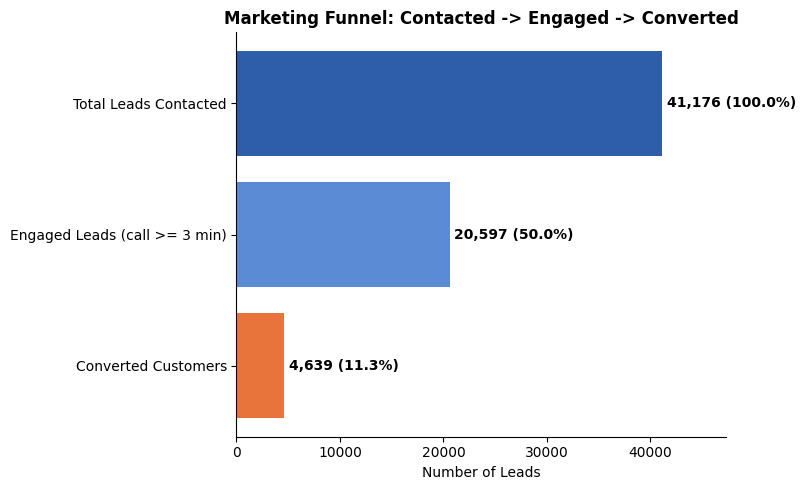

Contacted -> Engaged: 50.02%
Engaged -> Converted: 22.52%
Overall conversion (Contacted -> Converted): 11.27%


In [4]:
fig, ax = plt.subplots(figsize=(8,5))
colors = ['#2E5EAA', '#5B8BD4', '#E8743B']
bars = ax.barh(funnel['Stage'], funnel['Count'], color=colors)
for bar, c in zip(bars, funnel['Count']):
    ax.text(bar.get_width()+400, bar.get_y()+bar.get_height()/2,
            f"{c:,} ({c/stage1*100:.1f}%)", va='center', fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel("Number of Leads")
ax.set_title("Marketing Funnel: Contacted -> Engaged -> Converted", fontweight='bold')
ax.set_xlim(0, stage1*1.15)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Contacted -> Engaged: {stage2/stage1*100:.2f}%")
print(f"Engaged -> Converted: {stage3/stage2*100:.2f}%")
print(f"Overall conversion (Contacted -> Converted): {stage3/stage1*100:.2f}%")

**Key takeaway:** Roughly **half of all contacted leads never make it past a short call** — the
biggest drop-off in the whole funnel happens right at the first stage. Of the leads who *do* engage in
a real conversation, roughly 1 in 4.4 goes on to convert.


## 3. Conversion Rate by Channel (Cellular vs Telephone)

In [5]:
channel = df.groupby('contact')['converted'].agg(['sum','count'])
channel['rate_%'] = (channel['sum']/channel['count']*100).round(2)
channel = channel.sort_values('rate_%', ascending=False)
channel

,sum,count,rate_%
contact,,,
cellular,3852,26135,14.74
telephone,787,15041,5.23


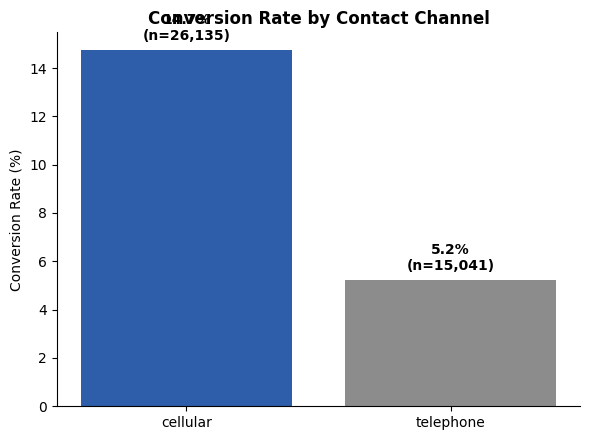

In [6]:
fig, ax = plt.subplots(figsize=(6,4.5))
bars = ax.bar(channel.index, channel['rate_%'], color=['#2E5EAA','#8C8C8C'])
for bar, v, n in zip(bars, channel['rate_%'], channel['count']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.4, f"{v:.1f}%\n(n={n:,})", ha='center', fontweight='bold')
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Contact Channel", fontweight='bold')
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Key takeaway:** **Cellular contact converts nearly 3x better than landline telephone** (14.7% vs
5.2%). Mobile-first outreach should be the default channel.


## 4. Conversion Rate by Month (Volume vs Quality)

In [7]:
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_stats = df.groupby('month')['converted'].agg(['sum','count'])
month_stats['rate_%'] = (month_stats['sum']/month_stats['count']*100).round(2)
month_stats = month_stats.reindex([m for m in month_order if m in month_stats.index])
month_stats

,sum,count,rate_%
month,,,
mar,276,546,50.55
apr,539,2631,20.49
may,886,13767,6.44
jun,559,5318,10.51
jul,648,7169,9.04
aug,655,6176,10.61
sep,256,570,44.91
oct,315,717,43.93
nov,416,4100,10.15


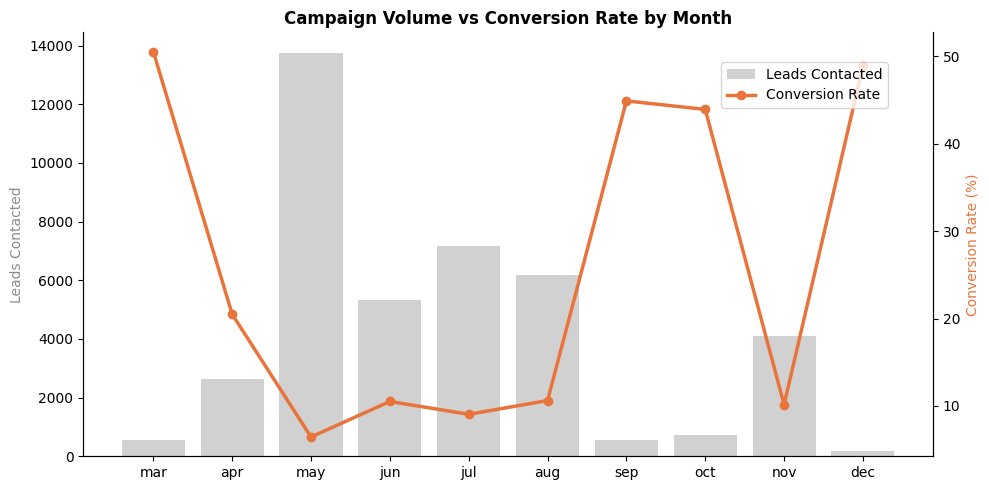

In [8]:
fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax1.bar(month_stats.index, month_stats['count'], color='#8C8C8C', alpha=0.4, label='Leads Contacted')
ax2.plot(month_stats.index, month_stats['rate_%'], color='#E8743B', marker='o', linewidth=2.5, label='Conversion Rate')
ax1.set_ylabel("Leads Contacted", color='#8C8C8C')
ax2.set_ylabel("Conversion Rate (%)", color='#E8743B')
ax1.set_title("Campaign Volume vs Conversion Rate by Month", fontweight='bold')
for s in ['top']: ax1.spines[s].set_visible(False); ax2.spines[s].set_visible(False)
fig.legend(loc='upper right', bbox_to_anchor=(0.9,0.88))
plt.tight_layout()
plt.show()

**Key takeaway:** The busiest months (May, Jun, Jul, Aug) have the **lowest** conversion rates
(6–10%), while low-volume months like March, September, October, and December convert at **44–50%**.
This is a classic quality-vs-quantity trade-off: mass campaigns in peak months dilute lead quality,
while smaller, likely better-targeted campaigns in off-peak months convert far more efficiently.


## 5. Conversion Rate by Previous Campaign Outcome (Retargeting Value)

In [9]:
po = df.groupby('poutcome')['converted'].agg(['sum','count'])
po['rate_%'] = (po['sum']/po['count']*100).round(2)
po = po.sort_values('rate_%', ascending=False)
po

,sum,count,rate_%
poutcome,,,
success,894,1373,65.11
failure,605,4252,14.23
nonexistent,3140,35551,8.83


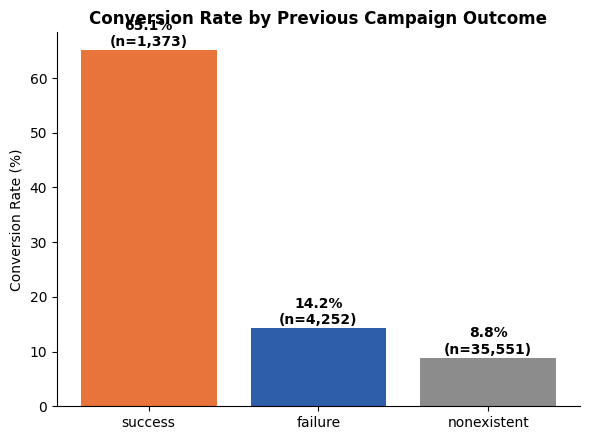

In [10]:
fig, ax = plt.subplots(figsize=(6,4.5))
bars = ax.bar(po.index, po['rate_%'], color=['#E8743B','#2E5EAA','#8C8C8C'])
for bar, v, n in zip(bars, po['rate_%'], po['count']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.8, f"{v:.1f}%\n(n={n:,})", ha='center', fontweight='bold')
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Previous Campaign Outcome", fontweight='bold')
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Key takeaway:** Leads with a **prior successful conversion convert at 65.1%** — nearly 6x the
baseline rate. Re-engaging past customers is by far the highest-ROI segment in this entire dataset.


## 6. Conversion Rate by Occupation Segment

In [11]:
job = df.groupby('job')['converted'].agg(['sum','count'])
job['rate_%'] = (job['sum']/job['count']*100).round(2)
job = job.sort_values('rate_%', ascending=False)
job

,sum,count,rate_%
job,,,
student,275,875,31.43
retired,434,1718,25.26
unemployed,144,1014,14.20
admin.,1351,10419,12.97
management,328,2924,11.22
unknown,37,330,11.21
technician,730,6739,10.83
self-employed,149,1421,10.49
housemaid,106,1060,10.00


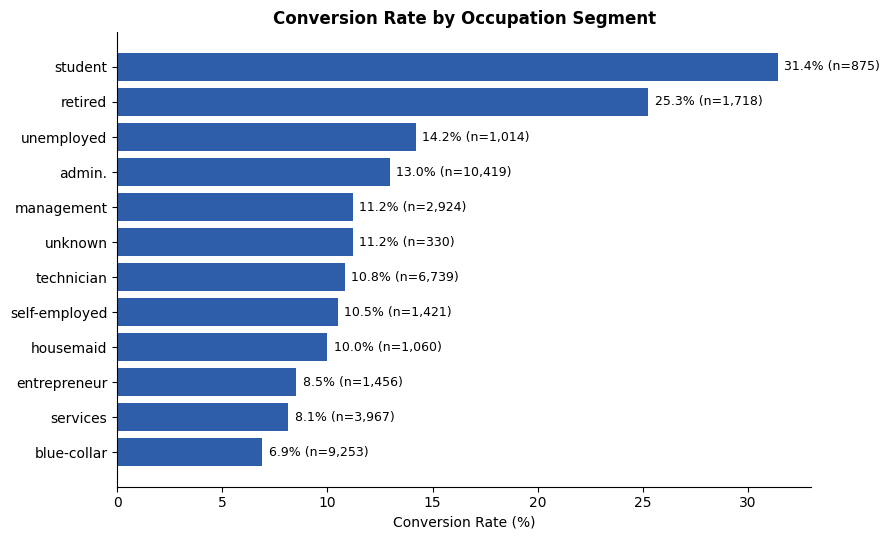

In [12]:
fig, ax = plt.subplots(figsize=(9,5.5))
bars = ax.barh(job.index, job['rate_%'], color='#2E5EAA')
for bar, v, n in zip(bars, job['rate_%'], job['count']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f"{v:.1f}% (n={n:,})", va='center', fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Occupation Segment", fontweight='bold')
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Key takeaway:** **Students (31.4%)** and **retirees (25.2%)** convert far above average, while
**blue-collar (6.9%)** and **services (8.1%)** workers convert well below average. These two segments
likely have more disposable income/time and less friction in adopting a savings product.


## 7. Call Engagement Duration vs Conversion

In [13]:
df['duration_bucket'] = pd.cut(df['duration'], bins=[0,60,120,180,300,600,5000],
                                labels=['0-1m','1-2m','2-3m','3-5m','5-10m','10m+'])
db = df.groupby('duration_bucket', observed=True)['converted'].agg(['sum','count'])
db['rate_%'] = (db['sum']/db['count']*100).round(2)
db

,sum,count,rate_%
duration_bucket,,,
0-1m,1,4280,0.02
1-2m,165,8628,1.91
2-3m,398,7784,5.11
3-5m,953,9278,10.27
5-10m,1438,7738,18.58
10m+,1684,3464,48.61


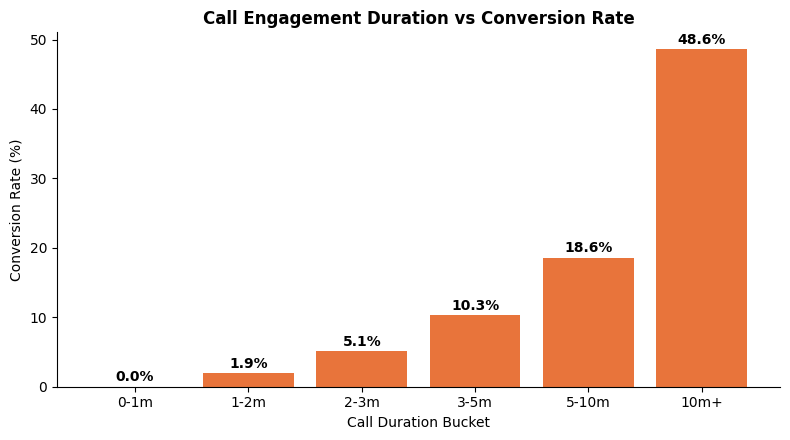

In [14]:
fig, ax = plt.subplots(figsize=(8,4.5))
bars = ax.bar(db.index.astype(str), db['rate_%'], color='#E8743B')
for bar, v in zip(bars, db['rate_%']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.8, f"{v:.1f}%", ha='center', fontweight='bold')
ax.set_xlabel("Call Duration Bucket")
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Call Engagement Duration vs Conversion Rate", fontweight='bold')
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Key takeaway:** Conversion climbs almost linearly with call length, from **~0% under 1 minute**
to **48.6% for calls over 10 minutes**. This confirms `duration` is a strong quality signal for the
funnel, and that agent training/scripting to keep prospects engaged longer directly drives conversions.


## 8. Summary of Key Insights

1. **Biggest drop-off is at first contact** — ~50% of leads never engage in a meaningful (3+ min) call.
2. **Cellular outreach converts ~3x better than landline telephone** (14.7% vs 5.2%).
3. **Quality beats quantity** — high-volume months (May–Aug) convert far worse than low-volume,
   likely better-targeted months (Mar, Sep, Oct, Dec).
4. **Retargeting past successful customers is the single highest-value segment** (65.1% conversion).
5. **Students and retirees convert far above average**; blue-collar and services workers convert below.
6. **Longer, more engaged calls convert dramatically better**, confirming call quality/agent training matters.

## 9. Recommendations

- **Prioritize cellular contact** over landline wherever a mobile number is available.
- **Build a systematic retargeting flow** for clients with a previous successful outcome — this segment
  alone converts at 6x the baseline rate and is currently under-leveraged (only 1,373 of 41,188 records).
- **Shift budget/effort toward off-peak, smaller, targeted campaigns** rather than mass outreach in
  May–August, or apply the same tighter targeting logic used in those months to peak months.
- **Segment campaigns by occupation** — lead with students and retirees in acquisition campaigns, and
  use tailored messaging/incentives for lower-converting segments like blue-collar workers.
- **Invest in call-opening scripts** that get prospects past the critical first 1–2 minutes, since
  conversion rates rise sharply the longer a prospect stays engaged.
